# HDFC Bank Stock Price Prediction using Gradient Boosting

Predicting tomorrow's closing price of HDFC Bank using a Gradient Boosting Regressor.

**Features:** Open, High, Low, Volume, Prev_Close, Price_Change, HL_Spread, OC_Spread, MA_5, MA_10

**Target:** Next day's Close price

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings('ignore')

## Download HDFC Stock Data

In [10]:
df = yf.download('HDFCBANK.NS', start='2015-01-01')
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

print(f"Shape: {df.shape}")
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (2890, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,213.700836,214.228335,212.129589,213.465152,3544940
2015-01-02,216.674988,217.572843,213.330484,213.330484,5900384
2015-01-05,214.845627,217.853435,214.385465,217.729982,4796000
2015-01-06,211.501099,214.710929,210.446116,214.138549,8219680
2015-01-07,212.118393,213.543733,210.154334,210.928737,5746112


In [11]:
df.tail(5)

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-03,706.650024,712.599976,705.000000,705.000000,27770641
2026-09-04,712.099976,716.500000,708.349976,708.349976,14488024
2026-09-07,710.500000,713.000000,707.049988,712.099976,12180390
2026-09-08,703.000000,708.900024,703.000000,707.099976,19883515
2026-09-09,687.099976,700.000000,687.099976,698.000000,39138036


## Feature Engineering

In [3]:
df = df[['Open', 'High', 'Low', 'Volume', 'Close']].copy()
df['Prev_Close'] = df['Close'].shift(1)
df['Price_Change'] = df['Close'] - df['Open']
df['HL_Spread'] = df['High'] - df['Low']
df['OC_Spread'] = df['Close'] - df['Open']
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_10'] = df['Close'].rolling(10).mean()
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Volume', 'Prev_Close', 'Price_Change', 'HL_Spread', 'OC_Spread', 'MA_5', 'MA_10']
X = df[features]
y = df['Target']

print(f"Features shape: {X.shape}")

Features shape: (2880, 10)


## Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 2304
Test size: 576


## Train Gradient Boosting Model

In [5]:
model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.8, random_state=42)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


## Cross Validation & Evaluation

In [6]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R\u00b2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")

R² Score: 0.9984
MAE: 6.0928
Mean CV Score: 0.9978


## Visualizations

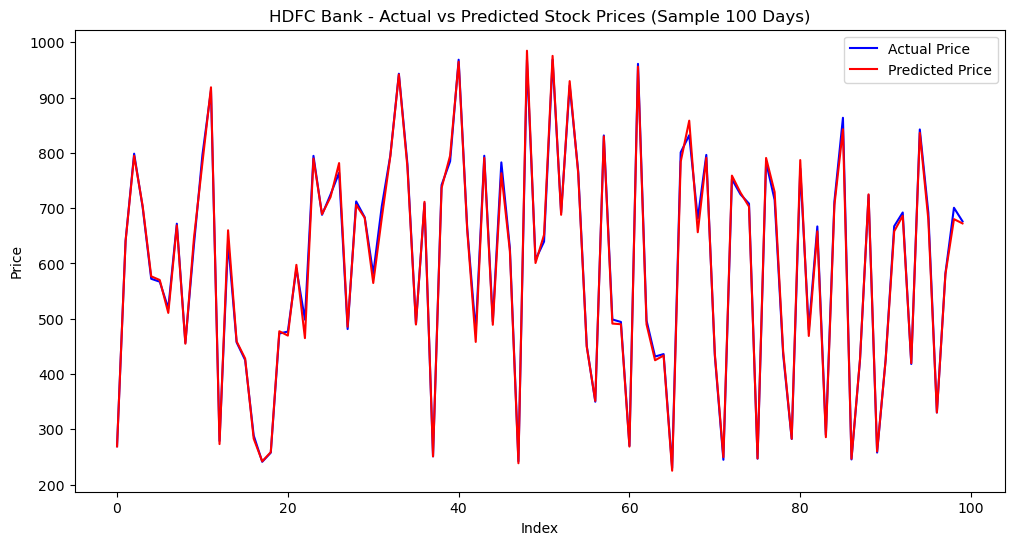

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Price', color='blue')
plt.plot(y_pred[:100], label='Predicted Price', color='red')
plt.title('HDFC Bank - Actual vs Predicted Stock Prices (Sample 100 Days)')
plt.xlabel('Index')
plt.ylabel('Price')
plt.legend()
plt.show()

## Save Model

In [8]:
joblib.dump(model, 'hdfc_model.pkl')
print('Model saved as hdfc_model.pkl')

Model saved as hdfc_model.pkl
